# siRNA dataset exploration

This notebook demonstrates a descriptive workflow using the repository's **toy/example dataset only**. It does not establish biological findings or train a predictive model.

Features are calculated on the antisense sequence. Confirm strand convention and any chemistry-specific sequence representation before applying this workflow to real data.

## Section 1 — Load dataset

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Enable imports when the notebook runs from notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_sirna_data
from src.data_quality import run_quality_checks
from src.sequence_features import add_sequence_features

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'example_sirna_dataset.csv'
FIGURE_DIR = PROJECT_ROOT / 'figures'
FIGURE_DIR.mkdir(exist_ok=True)

df = load_sirna_data(DATA_PATH)
print('Loaded toy/example data only — not experimental evidence.')
df.head()

Loaded toy/example data only — not experimental evidence.


,sirna_id,target_gene,sense_sequence,antisense_sequence,chemical_modification,activity_value,activity_type,cell_line,assay_method,concentration,treatment_time,reference
0,TOY_001,EXAMPLE1,AUGCAUGCAUGCAUGCAUGCA,UGCAUGCAUGCAUGCAUGCAU,unmodified (toy),42.0,toy relative knockdown (%),HeLa (toy),RT-qPCR (toy),10 nM,24 h,TOY DATA ONLY - illustrative record 1
1,TOY_002,EXAMPLE1,GCAUAGCUAGCAUAGCUAGCU,AGCUAGCAUAGCUAGCAUAGC,2'-OMe annotation (toy),55.0,toy relative knockdown (%),HeLa (toy),RT-qPCR (toy),10 nM,24 h,TOY DATA ONLY - illustrative record 2
2,TOY_003,EXAMPLE2,AAUUGGCCAAUUGGCCAAUUG,CAAUUGGCCAAUUGGCCAAUU,unmodified (toy),31.0,toy relative knockdown (%),HepG2 (toy),luciferase reporter (toy),5 nM,48 h,TOY DATA ONLY - illustrative record 3
3,TOY_004,EXAMPLE2,CGUAACGUAACGUAACGUAAC,GUUACGUUACGUUACGUUACGU,phosphorothioate annotation (toy),67.0,toy relative knockdown (%),HepG2 (toy),luciferase reporter (toy),5 nM,48 h,TOY DATA ONLY - illustrative record 4
4,TOY_005,EXAMPLE3,UUAAUCGGAUUAAUCGGAUUA,UAAUCCGAUUAAUCCGAUUAA,unmodified (toy),48.0,toy relative knockdown (%),A549 (toy),RT-qPCR (toy),20 nM,24 h,TOY DATA ONLY - illustrative record 5


## Section 2 — Dataset overview

Review structure and quality flags before deriving features. Quality checks report issues but do not alter source data.

In [2]:
print(f'Rows: {len(df)}')
print(f'Columns: {len(df.columns)}')
display(df.dtypes.to_frame('dtype'))

quality_report = run_quality_checks(df)
print('Missing values by column:')
display(pd.Series(quality_report['missing_values_by_column'], name='missing_values'))
print('Duplicate paired-sequence rows:', quality_report['duplicate_sequence_rows'])
print('Invalid sense rows:', quality_report['invalid_sense_sequence_rows'])
print('Invalid antisense rows:', quality_report['invalid_antisense_sequence_rows'])
display(pd.Series(quality_report['activity_type_distribution'], name='count'))

Rows: 8
Columns: 12


,dtype
sirna_id,object
target_gene,object
sense_sequence,object
antisense_sequence,object
chemical_modification,object
activity_value,float64
activity_type,object
cell_line,object
assay_method,object
concentration,object


Missing values by column:


sirna_id                 0
target_gene              0
sense_sequence           0
antisense_sequence       0
chemical_modification    0
activity_value           0
activity_type            0
cell_line                0
assay_method             0
concentration            0
treatment_time           0
reference                0
Name: missing_values, dtype: int64

Duplicate paired-sequence rows: []
Invalid sense rows: []
Invalid antisense rows: []


toy relative knockdown (%)    8
Name: count, dtype: int64

## Section 3 — Sequence feature calculation

These are basic descriptive features, not a validated efficacy scoring system.

In [3]:
feature_df = add_sequence_features(df, sequence_column='antisense_sequence')
feature_columns = [
    'sirna_id', 'antisense_sequence', 'sequence_length', 'GC_content',
    'A_fraction', 'U_fraction', 'G_fraction', 'C_fraction',
    '5_prime_base', 'seed_region'
]
feature_df[feature_columns]

,sirna_id,antisense_sequence,sequence_length,GC_content,A_fraction,U_fraction,G_fraction,C_fraction,5_prime_base,seed_region
0,TOY_001,UGCAUGCAUGCAUGCAUGCAU,21,0.476190,0.238095,0.285714,0.238095,0.238095,U,UGCAUGC
1,TOY_002,AGCUAGCAUAGCUAGCAUAGC,21,0.476190,0.333333,0.190476,0.238095,0.238095,A,AGCUAGC
2,TOY_003,CAAUUGGCCAAUUGGCCAAUU,21,0.428571,0.285714,0.285714,0.190476,0.238095,C,CAAUUGG
3,TOY_004,GUUACGUUACGUUACGUUACGU,22,0.409091,0.181818,0.409091,0.227273,0.181818,G,GUUACGU
4,TOY_005,UAAUCCGAUUAAUCCGAUUAA,21,0.285714,0.380952,0.333333,0.095238,0.190476,U,UAAUCCG
5,TOY_006,GCCGCUAAUGCCGCUAAUGCC,21,0.619048,0.190476,0.190476,0.238095,0.380952,G,GCCGCUA
6,TOY_007,UACGUACGUACGUACGUACGU,21,0.476190,0.238095,0.285714,0.238095,0.238095,U,UACGUAC
7,TOY_008,AUUGGGCCAUUGGGCCAUUGG,21,0.571429,0.142857,0.285714,0.380952,0.190476,A,AUUGGGC


## Section 4 — Visualisation

The plots below describe the toy rows. They must not be read as a real siRNA distribution or as evidence of sequence–activity relationships.

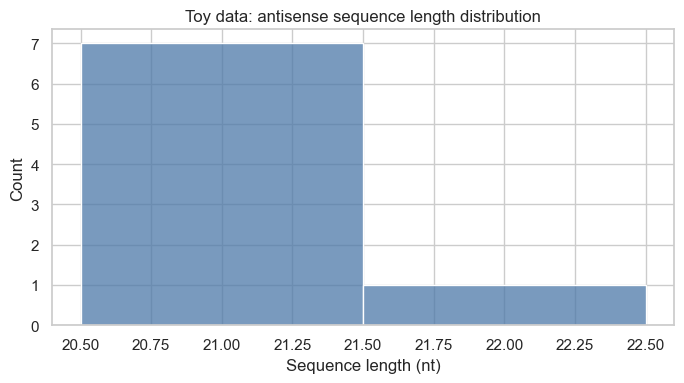

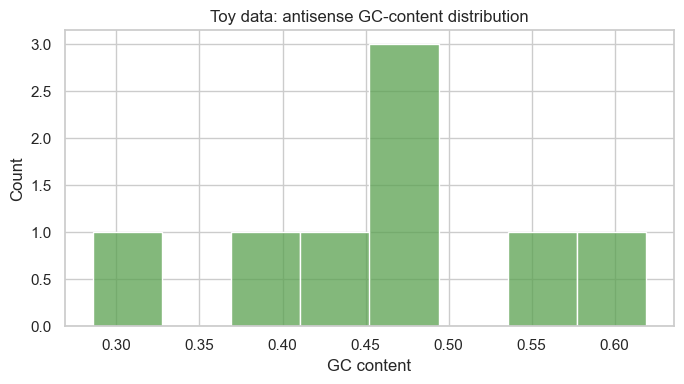

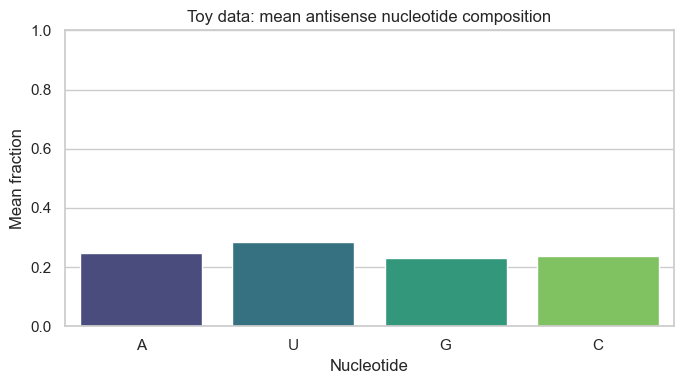

In [4]:
sns.set_theme(style='whitegrid', context='notebook')

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(feature_df['sequence_length'].dropna(), discrete=True, ax=ax, color='#4C78A8')
ax.set(title='Toy data: antisense sequence length distribution', xlabel='Sequence length (nt)', ylabel='Count')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'toy_sequence_length_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(feature_df['GC_content'].dropna(), bins=8, ax=ax, color='#59A14F')
ax.set(title='Toy data: antisense GC-content distribution', xlabel='GC content', ylabel='Count')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'toy_gc_content_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

composition = feature_df[['A_fraction', 'U_fraction', 'G_fraction', 'C_fraction']].mean().rename(lambda x: x[0])
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=composition.index, y=composition.values, palette='viridis', ax=ax)
ax.set(title='Toy data: mean antisense nucleotide composition', xlabel='Nucleotide', ylabel='Mean fraction', ylim=(0, 1))
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'toy_nucleotide_composition.png', dpi=200, bbox_inches='tight')
plt.show()

## Section 5 — Context summary

Counts preserve reported experimental context. In a real integrated dataset, inspect these summaries before pooling observations across studies.

In [5]:
for column in ['cell_line', 'assay_method', 'chemical_modification']:
    print(f"\n{column.replace('_', ' ').title()} (toy data):")
    display(df[column].value_counts(dropna=False).rename('count').to_frame())

# Optional next curation step for real data:
# feature_df.to_csv(PROJECT_ROOT / 'data' / 'processed' / 'sirna_features.csv', index=False)


Cell Line (toy data):


,count
HeLa (toy),2
HepG2 (toy),2
A549 (toy),2
HEK293 (toy),2



Assay Method (toy data):


,count
RT-qPCR (toy),4
luciferase reporter (toy),2
western blot (toy),2



Chemical Modification (toy data):


,count
unmodified (toy),4
2'-OMe annotation (toy),2
phosphorothioate annotation (toy),1
2'-F annotation (toy),1
